In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn import preprocessing
from xgboost import XGBClassifier 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, precision_score, recall_score, f1_score

In [2]:
data = pd.read_csv('../../../data/labeled_dataset.csv')


In [3]:
data['Date'] = pd.to_datetime(data['Date'])

In [4]:
data['regime_binary']= np.where(data['regime']=='bull',1,0)


In [5]:
data['Risk_Adj_Return_20d'] = data['Return_20d'] / (data['VIX'] + 0.00001)

data['SPY_Volume_20d_MA'] = data['SPY Volume'].rolling(window=20).mean()

data['Relative_Volume'] = data['SPY Volume'] / data['SPY_Volume_20d_MA']

data['MACD_Hist_Accel'] = data['MACD_Hist'] - data['MACD_Hist'].shift(1)

data = data.drop(columns=['SPY_Volume_20d_MA']).dropna()

In [6]:
# data['lagged_target_1'] = data['regime_binary'].shift(-1)
# data['lagged_target_4'] = data['regime_binary'].shift(-5)
data['lagged_target_20'] = data['regime_binary'].shift(-20)

In [7]:
data_1 = data.dropna(subset=['lagged_target_20'])
# data_1 = data.dropna(subset=['lagged_target_1'])



In [8]:
stationary_features = [
    'Return', 'Return_5d', 'Return_20d', 'Return_Smooth', 
    'RSI_14', 'MACD_Hist', 'Drawdown', 
    'VIX', 'VIX_Change', 'VIX_Change_5d', 
    'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Unemployment',
    'Risk_Adj_Return_20d','Relative_Volume',
    'MACD_Hist_Accel'
]

In [9]:

X = data_1[stationary_features]
y = data_1['lagged_target_20']



In [10]:
total_rows = len(data_1)

train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85) 


scaler = preprocessing.StandardScaler()

X_train = X.iloc[:train_end]
X_train = scaler.fit_transform(X_train)
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
X_val = scaler.transform(X_val)
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
X_test = scaler.transform(X_test)
y_test = y.iloc[val_end:]

In [11]:

logit_model = sm.Logit(y_train, sm.add_constant(X_train))
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.569475
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       lagged_target_20   No. Observations:                 5618
Model:                          Logit   Df Residuals:                     5600
Method:                           MLE   Df Model:                           17
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.1604
Time:                        15:38:21   Log-Likelihood:                -3199.3
converged:                       True   LL-Null:                       -3810.6
Covariance Type:            nonrobust   LLR p-value:                1.818e-249
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3772      0.031     12.173      0.000       0.316       0.438
x1            -0.0365      0.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'const'),
  Text(1, 0, 'Return'),
  Text(2, 0, 'Return_5d'),
  Text(3, 0, 'Return_20d'),
  Text(4, 0, 'Return_Smooth'),
  Text(5, 0, 'RSI_14'),
  Text(6, 0, 'MACD_Hist'),
  Text(7, 0, 'Drawdown'),
  Text(8, 0, 'VIX'),
  Text(9, 0, 'VIX_Change'),
  Text(10, 0, 'VIX_Change_5d'),
  Text(11, 0, 'GDP_YoY'),
  Text(12, 0, 'Core_Inflation_YoY'),
  Text(13, 0, 'M2_YoY'),
  Text(14, 0, 'Unemployment'),
  Text(15, 0, 'Risk_Adj_Return_20d'),
  Text(16, 0, 'Relative_Volume'),
  Text(17, 0, 'MACD_Hist_Accel')])

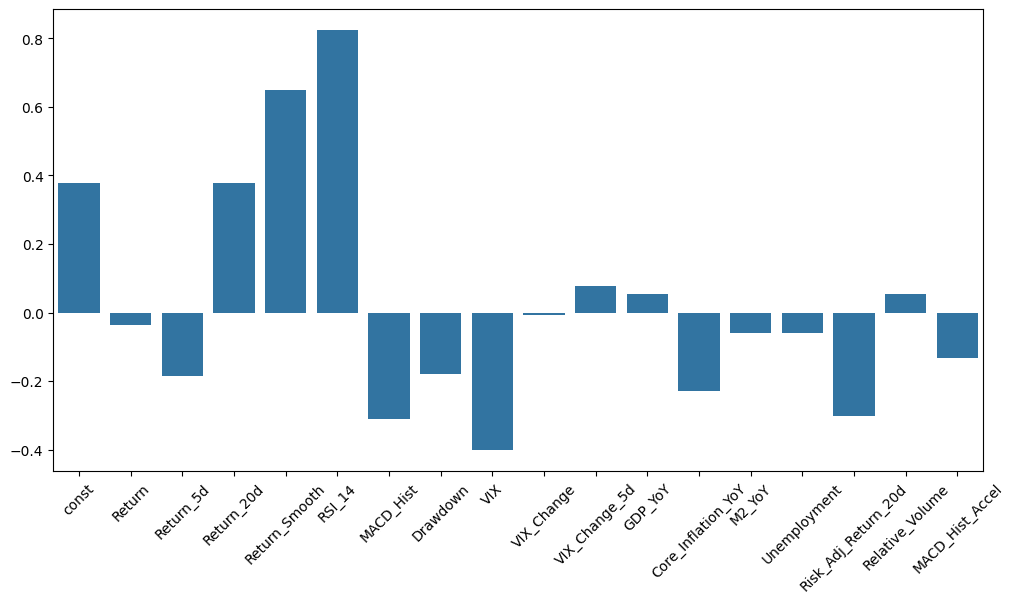

In [12]:
plt.figure(figsize=(12, 6))
names = ['const'] + list(X.columns)
sns.barplot(x=names, y=result.params.values)
plt.xticks(rotation=45)

In [13]:
threshold = 0.5
y_pred_prob_val = result.predict(sm.add_constant(X_val))
y_pred_val = (y_pred_prob_val >= threshold).astype(int)


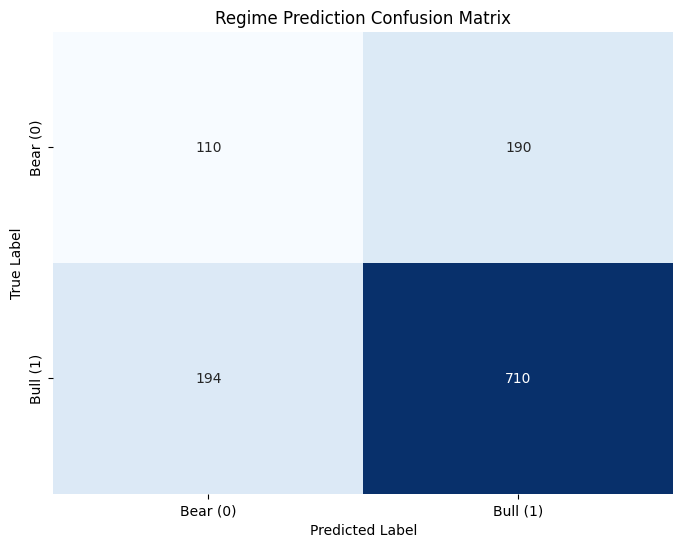

In [14]:

cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bear (0)', 'Bull (1)'], 
            yticklabels=['Bear (0)', 'Bull (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Regime Prediction Confusion Matrix')
plt.show()

In [15]:

print(classification_report(y_val, y_pred_val, target_names=['Bear (0)', 'Bull (1)']))

              precision    recall  f1-score   support

    Bear (0)       0.36      0.37      0.36       300
    Bull (1)       0.79      0.79      0.79       904

    accuracy                           0.68      1204
   macro avg       0.58      0.58      0.58      1204
weighted avg       0.68      0.68      0.68      1204



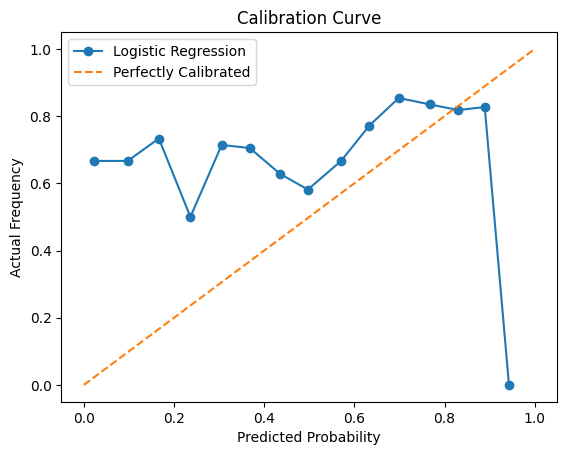

In [16]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_val, y_pred_prob_val, n_bins=15)

plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Frequency')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import fbeta_score
thresholds = np.linspace(0, 1, 50)
beta = 2 
f_scores = []
for t in thresholds:

    y_pred_temp = (y_pred_prob_val >= t).astype(int)
    f_scores.append(fbeta_score(y_val, y_pred_temp, beta=beta, pos_label=0))

best_threshold_f = thresholds[np.argmax(f_scores)]
print(f"Best Threshold (F-{beta} Score): {best_threshold_f:.4f}")

Best Threshold (F-2 Score): 0.9592


Text(0, 0.5, 'F_beta_score')

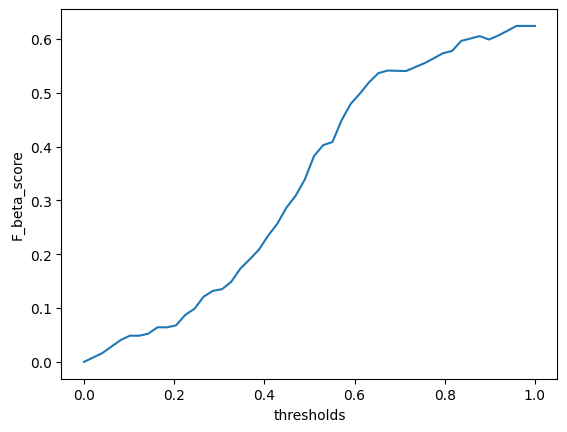

In [18]:
sns.lineplot(x=thresholds, y=f_scores)
plt.xlabel('thresholds')
plt.ylabel('F_beta_score')

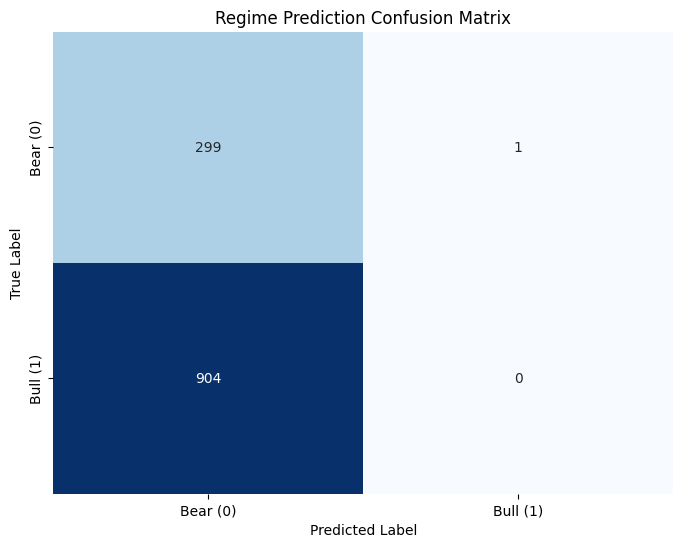

              precision    recall  f1-score   support

    Bear (0)       0.25      1.00      0.40       300
    Bull (1)       0.00      0.00      0.00       904

    accuracy                           0.25      1204
   macro avg       0.12      0.50      0.20      1204
weighted avg       0.06      0.25      0.10      1204



In [19]:
threshold = 0.95
y_pred_prob_val = result.predict(sm.add_constant(X_val))
y_pred_val = (y_pred_prob_val >= threshold).astype(int)
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Bear (0)', 'Bull (1)'], 
            yticklabels=['Bear (0)', 'Bull (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Regime Prediction Confusion Matrix')
plt.show()
print(classification_report(y_val, y_pred_val, target_names=['Bear (0)', 'Bull (1)']))

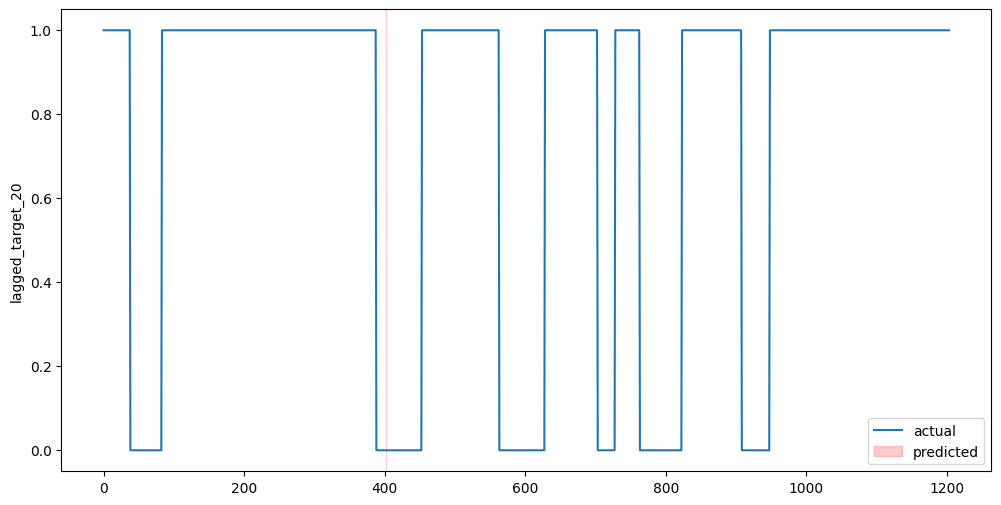

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val, label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_val == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

In [21]:
model =  XGBClassifier(n_estimators=150, random_state=0,max_depth=5, learning_rate=0.1)

model.fit(
    X_train, 
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10  
)

[0]	validation_0-logloss:0.64028	validation_1-logloss:0.61050
[10]	validation_0-logloss:0.43716	validation_1-logloss:0.56981
[20]	validation_0-logloss:0.34443	validation_1-logloss:0.55062


[30]	validation_0-logloss:0.27448	validation_1-logloss:0.57740
[40]	validation_0-logloss:0.22661	validation_1-logloss:0.57949
[50]	validation_0-logloss:0.19101	validation_1-logloss:0.61854
[60]	validation_0-logloss:0.16348	validation_1-logloss:0.63675
[70]	validation_0-logloss:0.14580	validation_1-logloss:0.65730
[80]	validation_0-logloss:0.13143	validation_1-logloss:0.67886
[90]	validation_0-logloss:0.11964	validation_1-logloss:0.69368
[100]	validation_0-logloss:0.10966	validation_1-logloss:0.71716
[110]	validation_0-logloss:0.09780	validation_1-logloss:0.73826
[120]	validation_0-logloss:0.08859	validation_1-logloss:0.75718
[130]	validation_0-logloss:0.07968	validation_1-logloss:0.78453
[140]	validation_0-logloss:0.07272	validation_1-logloss:0.79723
[149]	validation_0-logloss:0.06745	validation_1-logloss:0.81003


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
results = model.evals_result()

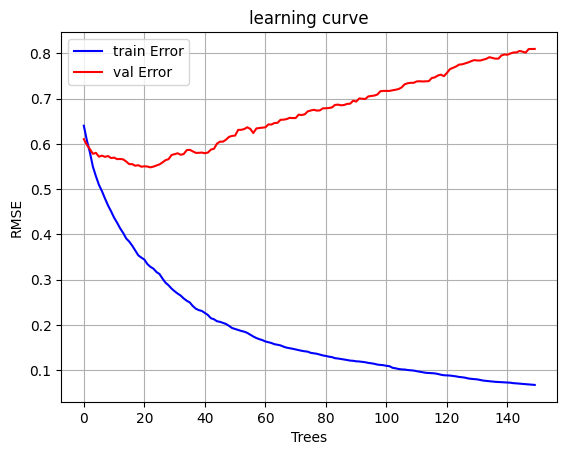

In [23]:
results = model.evals_result()
train_rmse = results['validation_0']['logloss']
val_rmse = results['validation_1']['logloss']

plt.plot(train_rmse, label='train Error', color='blue')
plt.plot(val_rmse, label='val Error', color='red')
plt.title('learning curve')
plt.xlabel('Trees')
plt.ylabel('RMSE')
plt.legend()
plt.grid()
plt.show()

<Axes: >

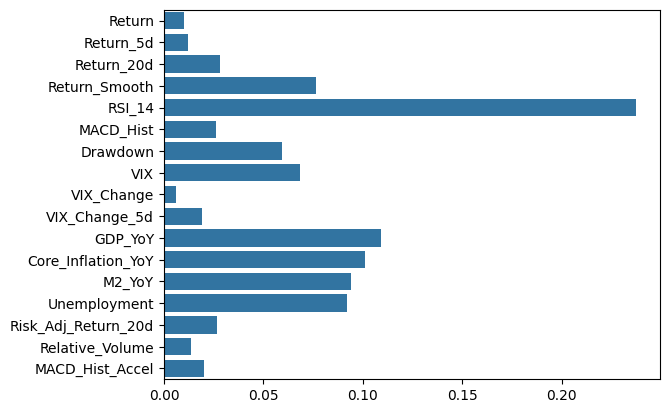

In [24]:
sns.barplot(x=model.feature_importances_, y=names[1:])

Best Threshold (Youden's J): 0.5359


<Axes: >

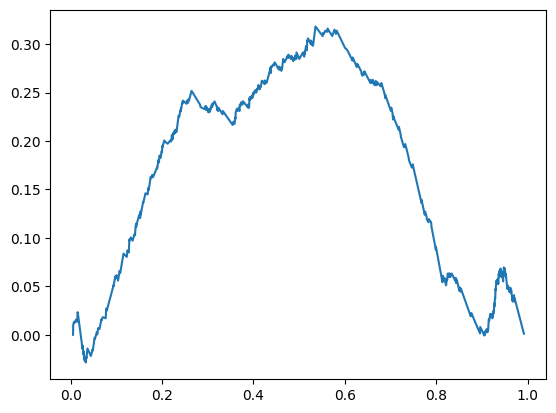

In [25]:
y_pred_prob_val = model.predict_proba(X_val)[:, 1].flatten()


fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob_val)
# J = TPR – FPR
j_scores = tpr - fpr
best_threshold = thresholds[np.argmax(j_scores)]
print(f"Best Threshold (Youden's J): {best_threshold:.4f}")
sns.lineplot(x=thresholds, y=j_scores)

In [26]:
# y_pred_val = model.predict(X_val)
best_threshold = 0.838
y_pred_val = (y_pred_prob_val >= best_threshold).astype(int)

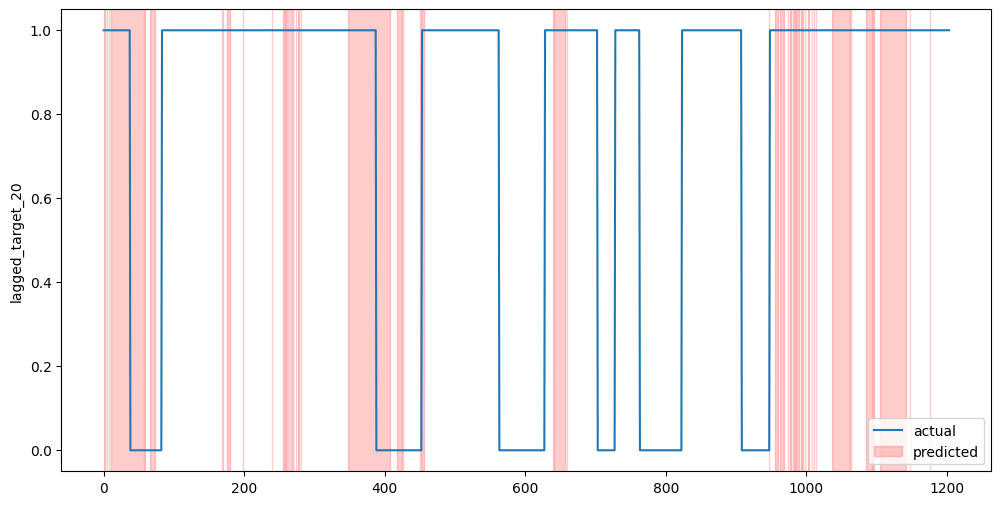

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val, label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_val == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

<Axes: xlabel='col_0', ylabel='lagged_target_20'>

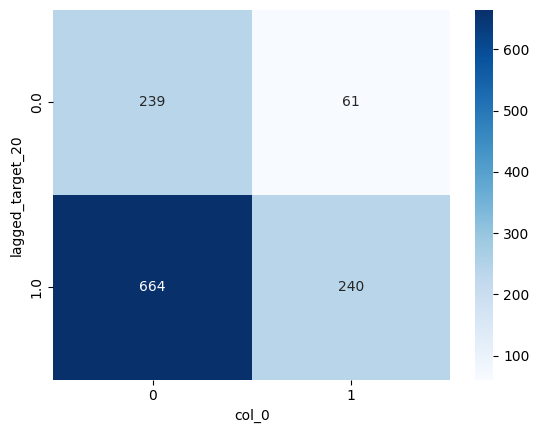

In [28]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

<Axes: xlabel='col_0', ylabel='lagged_target_20'>

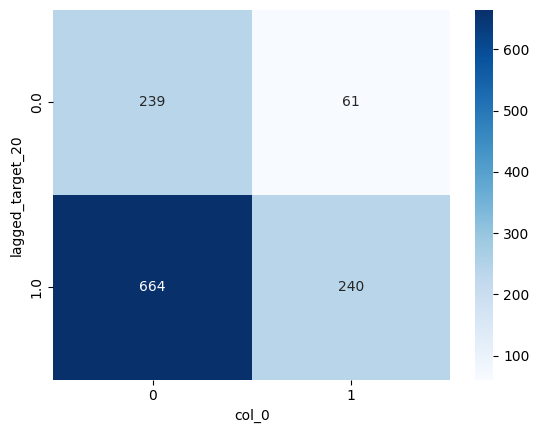

In [29]:
sns.heatmap(pd.crosstab(y_val, y_pred_val), annot=True, fmt='d', cmap='Blues')

In [30]:
import shap
import xgboost as xgb

X_val_df = pd.DataFrame(X_val, columns=names[1:])

# SHAP TreeExplainer can fail with newer XGBoost base_score format; use pred_contribs from booster.
booster = model.get_booster()
dval = xgb.DMatrix(X_val_df, feature_names=names[1:])
shap_contrib = booster.predict(dval, pred_contribs=True)

shap_values = shap.Explanation(
    values=shap_contrib[:, :-1],
    base_values=shap_contrib[:, -1],
    data=X_val_df.values,
    feature_names=names[1:],
)

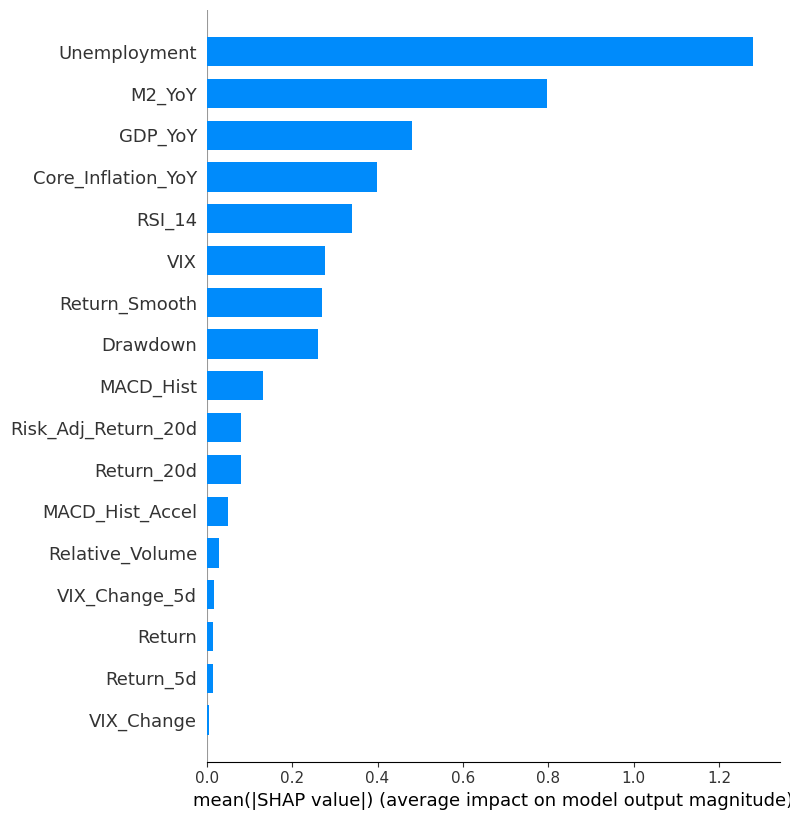

In [31]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_df, feature_names=names[1:], plot_type='bar')

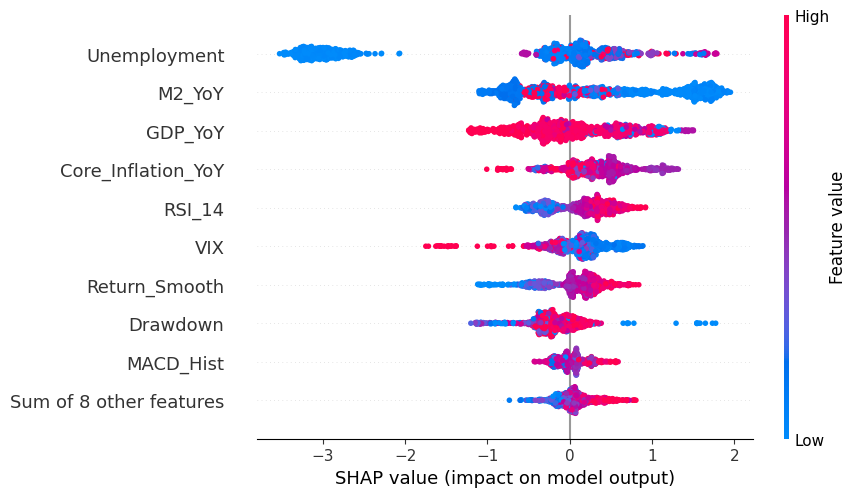

In [32]:
shap.plots.beeswarm(shap_values)


In [33]:
from pathlib import Path

LOGISTIC_OUTPUT_DIR = Path("../../../reports/trained_logistic/basecase_20days")
XGBOOST_OUTPUT_DIR = Path("../../../reports/trained_xgboost/basecase_20days")

LOGISTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
XGBOOST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

validation_dates = data_1["Date"].iloc[train_end:val_end].reset_index(drop=True)
test_dates = data_1["Date"].iloc[val_end:].reset_index(drop=True)

logistic_pred_prob_val = result.predict(sm.add_constant(X_val))
logistic_pred_val = (logistic_pred_prob_val >= threshold).astype(int)
logistic_pred_prob_test = result.predict(sm.add_constant(X_test))
logistic_pred_test = (logistic_pred_prob_test >= threshold).astype(int)

logistic_confusion = pd.DataFrame(
    confusion_matrix(y_val, logistic_pred_val),
    index=["actual_bear", "actual_bull"],
    columns=["pred_bear", "pred_bull"],
)
logistic_confusion.to_csv(LOGISTIC_OUTPUT_DIR / "confusion_matrix.csv")

logistic_metrics = pd.DataFrame([
    {
        "model": "logistic_regression",
        "split": "validation",
        "horizon": "20days",
        "accuracy": accuracy_score(y_val, logistic_pred_val),
        "precision": precision_score(y_val, logistic_pred_val, zero_division=0),
        "recall": recall_score(y_val, logistic_pred_val, zero_division=0),
        "f1_score": f1_score(y_val, logistic_pred_val, zero_division=0),
        "threshold": threshold,
    }
])
logistic_metrics.to_csv(LOGISTIC_OUTPUT_DIR / "validation_metrics.csv", index=False)

logistic_test_metrics = pd.DataFrame([
    {
        "model": "logistic_regression",
        "split": "test",
        "horizon": "20days",
        "accuracy": accuracy_score(y_test, logistic_pred_test),
        "precision": precision_score(y_test, logistic_pred_test, zero_division=0),
        "recall": recall_score(y_test, logistic_pred_test, zero_division=0),
        "f1_score": f1_score(y_test, logistic_pred_test, zero_division=0),
        "threshold": threshold,
    }
])
logistic_test_metrics.to_csv(LOGISTIC_OUTPUT_DIR / "test_metrics.csv", index=False)

pd.DataFrame({"feature": names, "coefficient": result.params.values}).to_csv(LOGISTIC_OUTPUT_DIR / "coefficients.csv", index=False)

pd.DataFrame({
    "Date": validation_dates,
    "y_true": y_val.reset_index(drop=True),
    "y_pred": pd.Series(logistic_pred_val).reset_index(drop=True),
    "y_pred_prob": pd.Series(logistic_pred_prob_val).reset_index(drop=True),
    "model": "logistic_regression",
    "split": "validation",
    "horizon": "20days",
}).to_csv(LOGISTIC_OUTPUT_DIR / "predictions.csv", index=False)

pd.DataFrame({
    "Date": test_dates,
    "y_true": y_test.reset_index(drop=True),
    "y_pred": pd.Series(logistic_pred_test).reset_index(drop=True),
    "y_pred_prob": pd.Series(logistic_pred_prob_test).reset_index(drop=True),
    "model": "logistic_regression",
    "split": "test",
    "horizon": "20days",
}).to_csv(LOGISTIC_OUTPUT_DIR / "test_predictions.csv", index=False)

plt.figure(figsize=(6, 5))
sns.heatmap(logistic_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix (20 Days)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(LOGISTIC_OUTPUT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val.reset_index(drop=True), label='actual')
plt.fill_between(
    range(len(X_val)),
    0,
    1,
    where=(pd.Series(logistic_pred_val).reset_index(drop=True) == 1),
    color='red',
    alpha=0.2,
    transform=plt.gca().get_xaxis_transform(),
    label='predicted',
)
plt.title('Logistic Regression Prediction Timeline (20 Days)')
plt.xlabel('Validation Observation')
plt.ylabel('Regime')
plt.legend()
plt.tight_layout()
plt.savefig(LOGISTIC_OUTPUT_DIR / "prediction_timeline.png", dpi=180, bbox_inches="tight")
plt.close()

xgb_pred_prob_test = model.predict_proba(X_test)[:, 1]
y_pred_test = (xgb_pred_prob_test >= best_threshold).astype(int)

xgb_confusion = pd.DataFrame(
    confusion_matrix(y_val, y_pred_val),
    index=["actual_bear", "actual_bull"],
    columns=["pred_bear", "pred_bull"],
)
xgb_confusion.to_csv(XGBOOST_OUTPUT_DIR / "confusion_matrix.csv")

xgb_metrics = pd.DataFrame([
    {
        "model": "xgboost",
        "split": "validation",
        "horizon": "20days",
        "accuracy": accuracy_score(y_val, y_pred_val),
        "precision": precision_score(y_val, y_pred_val, zero_division=0),
        "recall": recall_score(y_val, y_pred_val, zero_division=0),
        "f1_score": f1_score(y_val, y_pred_val, zero_division=0),
        "threshold": best_threshold,
    }
])
xgb_metrics.to_csv(XGBOOST_OUTPUT_DIR / "validation_metrics.csv", index=False)

xgb_test_metrics = pd.DataFrame([
    {
        "model": "xgboost",
        "split": "test",
        "horizon": "20days",
        "accuracy": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, zero_division=0),
        "recall": recall_score(y_test, y_pred_test, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_test, zero_division=0),
        "threshold": best_threshold,
    }
])
xgb_test_metrics.to_csv(XGBOOST_OUTPUT_DIR / "test_metrics.csv", index=False)

pd.DataFrame({
    "Date": validation_dates,
    "y_true": y_val.reset_index(drop=True),
    "y_pred": pd.Series(y_pred_val).reset_index(drop=True),
    "y_pred_prob": pd.Series(y_pred_prob_val).reset_index(drop=True),
    "model": "xgboost",
    "split": "validation",
    "horizon": "20days",
}).to_csv(XGBOOST_OUTPUT_DIR / "predictions.csv", index=False)

pd.DataFrame({
    "Date": test_dates,
    "y_true": y_test.reset_index(drop=True),
    "y_pred": pd.Series(y_pred_test).reset_index(drop=True),
    "y_pred_prob": pd.Series(xgb_pred_prob_test).reset_index(drop=True),
    "model": "xgboost",
    "split": "test",
    "horizon": "20days",
}).to_csv(XGBOOST_OUTPUT_DIR / "test_predictions.csv", index=False)
